# Milestone 4: Process Enhancement

In [ ]:
import copy
import pm4py
import pandas as pd
import os
from pathlib import Path

from pm4py.algo.evaluation.replay_fitness import algorithm as fitness_evaluator
from pm4py.algo.evaluation.precision import algorithm as precision_evaluator
from pm4py.visualization.petri_net import visualizer as pn_visualizer
from pm4py.objects.log.util import interval_lifecycle

DATA_DIR = Path.cwd().parent / "data"
OUTPUT_DIR = DATA_DIR / "milestone4"
if not OUTPUT_DIR.exists():
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Task a: Model extension with performance

**Requirements**:
- For each log, produce a table that shows, for each activity, the mean waiting time and the mean processing time; activities logged as a single event have waiting time only.
- From the table, report the top five activities by total waiting time.

**Explanation**:
- Waiting time = the gap between when the previous activity finished and when this activity starts. This is "idle time". Applicable to all activities.
- Processing time = the gap between an activity's start event and its complete event. This is actual work time. Only applicable to activities that record both a start and completion:
    - W_ activities (workflow tasks) → have both start and complete events → compute both waiting time and processing time
    - A_ activities (application events) and O_ activities (offer events) → single timestamp only → compute waiting time only

**Notes**
- For the clean log we use the built-in function `interval_lifecycle.to_interval()` from pm4py to calculate the processing time. However, this function doesn't work on the noised and recovered logs (perhaps because of inconsistent timestamp values). For the noised and recovered logs we manually map the start event and the complete event in the same case using activity name (`concept:name`) with the condition that start events always occur before complete events. If there are still duplicate complete events, we keep only the row where processing time is maximum.
- Why is this manual calculation valid for the noised and recovered logs? Because if we apply the same logic to the clean log, we obtain the same result as `interval_lifecycle.to_interval()` => We assume this matches the correct logic behind the built-in function.

In [ ]:
for case in ["clean", "noised", "recovered"]:
    # ---------------------------------------------------------------
    # STEP 0: Load the log
    # ---------------------------------------------------------------
    if case == "clean":
        df =  pm4py.read_xes(str(DATA_DIR / "BPI Challenge 2017.xes.gz"))
    elif case == "noised":
        df = pm4py.read_xes(str(DATA_DIR / "noised.xes.gz"))
    else: # case == "recovered":
        df = pm4py.read_xes(str(DATA_DIR / "recovered.xes.gz"))
    print(f"Loaded {case} log: {len(df)} events, "
        f"{df['case:concept:name'].nunique()} cases")

    df = df.sort_values(["case:concept:name", "time:timestamp"])
    # just to make sure that the logs are in the right format for pm4py
    log = pm4py.convert_to_event_log(df)
    
    # ---------------------------------------------------------------
    # STEP 1: Processing time for W_ activities (via interval format)
    # ---------------------------------------------------------------
    if case == "clean":
        # pm4py function converts a log to interval format
        log_interval = interval_lifecycle.to_interval(log)
        df_interval = pm4py.convert_to_dataframe(log_interval)
        
        # only keep W_ activities that have both timestamps
        df_interval_w = df_interval[df_interval["concept:name"].str.startswith("W_")]
        df_interval_w["processing_time_h"] = df_interval_w["@@duration"] / 3600
    else: # case == "noised" or case == "recovered" - to_inteval doesn't work
        df_interval_w = pd.merge(
            df[df['lifecycle:transition'] == 'start'],
            df[df['lifecycle:transition'] == 'complete'],
            on=["case:concept:name", "concept:name"],
            how='inner',
            suffixes=("_start", "_complete")
        )
        df_interval_w = df_interval_w[df_interval_w["time:timestamp_complete"] > df_interval_w["time:timestamp_start"]]
        df_interval_w['processing_time_h'] = round((df_interval_w["time:timestamp_complete"] - df_interval_w["time:timestamp_start"]).dt.total_seconds() / 3600, 5)
        df_interval_w = df_interval_w.sort_values("processing_time_h", ascending=False).drop_duplicates(
            subset="EventID_complete", 
            keep="first"  # after sorting by processing_time descending, "first" = maximum
        ) # we assume that the maximum processing time is the correct one

    mean_processing = (
        df_interval_w.groupby("concept:name")["processing_time_h"]
        .mean()
        .round(5)
        .rename("mean_processing_time_h")
    )
    
    # ---------------------------------------------------------------
    # STEP 2: Waiting time for ALL activities
    # ---------------------------------------------------------------
    df["prev_timestamp"] = df.groupby(
        "case:concept:name"
    )["time:timestamp"].shift(1)

    df["waiting_time_m"] = round((
        df["time:timestamp"] - df["prev_timestamp"]
    ).dt.total_seconds() / 60, 5)

    mean_waiting = (
        df.groupby("concept:name")["waiting_time_m"]
        .mean()
        .round(5)
        .rename("mean_waiting_time_m")
    )
    
    # ---------------------------------------------------------------
    # STEP 3: Combine into one table
    # ---------------------------------------------------------------
    df_timing = pd.DataFrame(mean_waiting).join(
        pd.DataFrame(mean_processing), how="left"
    ).reset_index()
    df_timing = df_timing.sort_values("mean_waiting_time_m", ascending=False)

    print(f"\n=== {case}: Top 5 bottlenecks by waiting time ===")
    print(df_timing.head(5))
    
    # ---------------------------------------------------------------
    # STEP 4: Save to CSV
    # ---------------------------------------------------------------
    df_timing.to_csv(OUTPUT_DIR / f"timing_{case}.csv", index=False)

In [ ]:
CSV_PATHS = {
    "clean":     "timing_clean.csv",
    "noised":    "timing_noised.csv",
    "recovered": "timing_recovered.csv",
}

for log_name, df_timing in CSV_PATHS.items():
    df_timing = pd.read_csv(OUTPUT_DIR / df_timing)
    print(f"\n=== {log_name}: Top 5 bottlenecks by waiting time ===")
    print(df_timing.head(5))


=== clean: Top 5 bottlenecks by waiting time ===
                 concept:name  mean_waiting_time_m  mean_processing_time_h
0  W_Personal Loan collection          33651.47233                     NaN
1                 A_Cancelled          29774.24768                     NaN
2                  O_Accepted           2872.90517                     NaN
3     W_Shortened completion            2820.27672                     NaN
4         W_Call after offers           1808.01516                35.88021

=== noised: Top 5 bottlenecks by waiting time ===
                                        concept:name  mean_waiting_time_m  \
0    A_Cancelled - Incident No. Application_88378711          44361.71740   
1  A_Cancelled - Incident No. Application_1091165384          38908.10205   
2   A_Cancelled - Incident No. Application_616691734          38907.40762   
3   A_Cancelled - Incident No. Application_418142057          38851.67782   
4  A_Cancelled - Incident No. Application_1547107498          38

## Task b: Repair the model
**Requirements**
- Starting from the reference model (the Petri net from M2) and your M3 conformance results, make one small tightening of an over-general part of the model on the clean log (a step it allows to be skipped or repeated that the clean log never does).
- Report a before/after table with the fitness and precision on the clean log. One documented change is sufficient.

**Idea**
- Inductive Miner adds silent (τ) transitions to handle optional paths and loops. Each silent transition allows the model to skip or repeat something. If the clean log never actually uses a particular silent transition, removing it tightens the model without breaking any clean trace. So the strategy is: find silent transitions whose removal makes precision go up the most, while fitness stays near or equal to 1.0, ideally.

In [47]:
net_clean, im_clean, fm_clean = pm4py.read_pnml(f"{DATA_DIR}/milestone3/reference_model_clean.pnml")

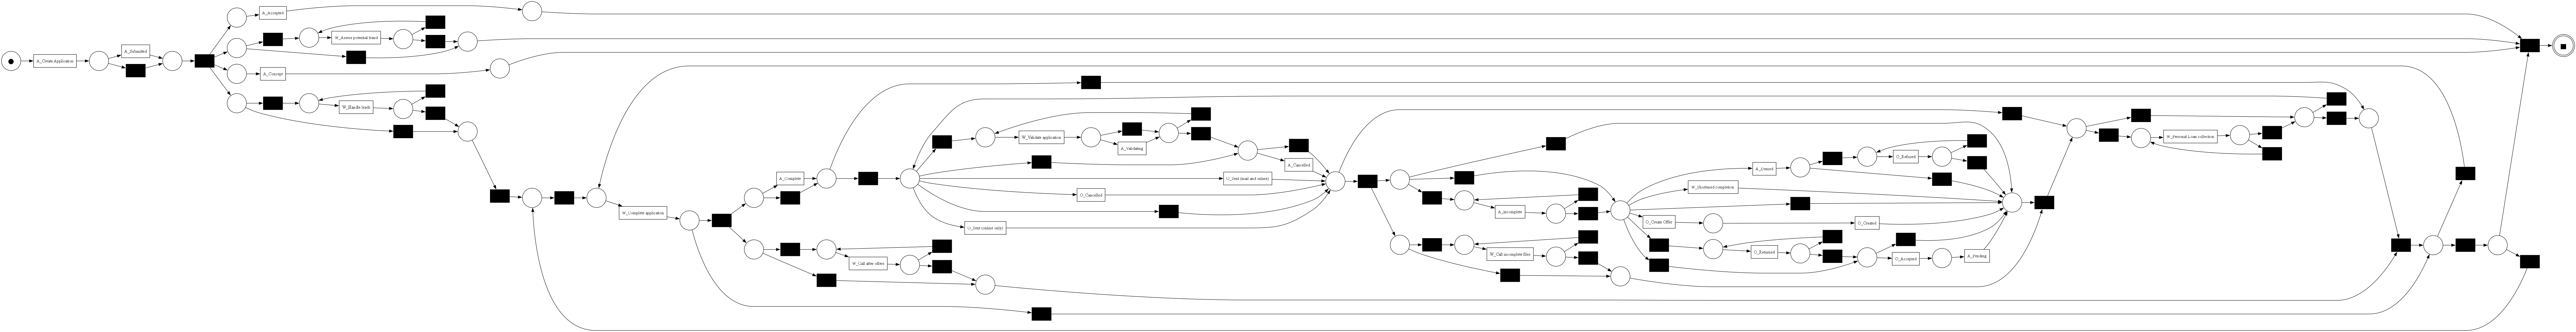

In [52]:
gviz = pn_visualizer.apply(net_clean, im_clean, fm_clean)
pn_visualizer.view(gviz)

### Step 1: Baseline fitness and precision on the clean log

In [55]:
fitness = fitness_evaluator.apply(log, net_clean, im_clean, fm_clean, variant=fitness_evaluator.Variants.TOKEN_BASED)    
precision = precision_evaluator.apply(log, net_clean, im_clean, fm_clean, variant=precision_evaluator.Variants.ETCONFORMANCE_TOKEN)

replaying log with TBR, completed traces :: 100%|██████████| 263907/263907 [1:07:55<00:00, 64.76it/s] 


In [56]:
print("=== BEFORE REPAIR ===")
print(f"Fitness:   {fitness['average_trace_fitness']:.4f}")
print(f"Precision: {precision:.4f}")

=== BEFORE REPAIR ===
Fitness:   1.0000
Precision: 0.1407


### Step 2: List all silent transitions in the net

In [57]:
silent_transitions = [t for t in net_clean.transitions if t.label is None]
print(f"\nFound {len(silent_transitions)} silent transitions in the model:")
for t in silent_transitions:
    print(f"  name={t.name}")


Found 61 silent transitions in the model:
  name=skip_27
  name=skip_45
  name=skip_14
  name=skip_28
  name=skip_62
  name=tauJoin_21
  name=skip_57
  name=skip_13
  name=skip_42
  name=skip_69
  name=skip_19
  name=init_loop_43
  name=skip_72
  name=skip_54
  name=skip_31
  name=tauJoin_4
  name=init_loop_23
  name=skip_64
  name=tauSplit_3
  name=skip_26
  name=init_loop_66
  name=init_loop_55
  name=skip_53
  name=skip_65
  name=skip_35
  name=skip_22
  name=skip_71
  name=skip_10
  name=skip_32
  name=init_loop_33
  name=skip_37
  name=skip_39
  name=tauSplit_40
  name=skip_46
  name=tauJoin_41
  name=init_loop_29
  name=init_loop_15
  name=init_loop_49
  name=skip_51
  name=skip_9
  name=skip_68
  name=skip_36
  name=skip_63
  name=skip_74
  name=init_loop_6
  name=skip_38
  name=init_loop_60
  name=init_loop_17
  name=skip_2
  name=skip_47
  name=skip_5
  name=init_loop_11
  name=skip_8
  name=tauSplit_20
  name=skip_70
  name=skip_48
  name=skip_73
  name=skip_58
  name=skip_5

### Step 3: Try removing each silent transition and measure impact
In this experiment, only the first silent (τ) transition was selected and removed to demonstrate the effect of the model change. This provides a simple example of how removing a silent transition can improve model precision while maintaining high fitness. Since the discovered model contains 61 silent transitions, a more comprehensive approach would evaluate the removal of each silent transition individually and compare the resulting fitness and precision scores. The best repair would be the one that achieves the largest improvement in precision while keeping fitness as close as possible to 1.0.

In [ ]:
results = []

for silent_t in silent_transitions[:1]:  # Limit to first 1 as the chosen one

    # Deep copy the net so we don't modify the original
    net_copy, im_copy, fm_copy = copy.deepcopy((net_clean, im_clean, fm_clean))

    # Find the same transition in the copy by name
    t_to_remove = next(
        t for t in net_copy.transitions if t.name == silent_t.name
    )

    # Remove all arcs connected to this transition, then the transition itself
    arcs_to_remove = set(t_to_remove.in_arcs) | set(t_to_remove.out_arcs)
    for arc in arcs_to_remove:
        net_copy.arcs.remove(arc)
    net_copy.transitions.remove(t_to_remove)
    
    repaired_net = net_copy
    repaired_im = im_copy
    repaired_fm = fm_copy

    # Measure fitness after removal
    try:
        f = pm4py.fitness_token_based_replay(log, net_copy, im_copy, fm_copy)
        p = pm4py.precision_token_based_replay(log, net_copy, im_copy, fm_copy)
        fitness_val = f["average_trace_fitness"]
        precision_val = p
    except Exception as e:
        fitness_val = None
        precision_val = None

    results.append({
        "transition_name": silent_t.name,
        "fitness_after":   round(fitness_val, 4) if fitness_val else "ERROR",
        "precision_after": round(precision_val, 4) if precision_val else "ERROR",
    })

    print(f"Removed {silent_t.name}: fitness={fitness_val:.4f}, precision={precision_val:.4f}")

replaying log with TBR, completed traces :: 100%|██████████| 263907/263907 [32:35<00:00, 134.93it/s]  


Removed skip_27: fitness=0.9741, precision=0.3685


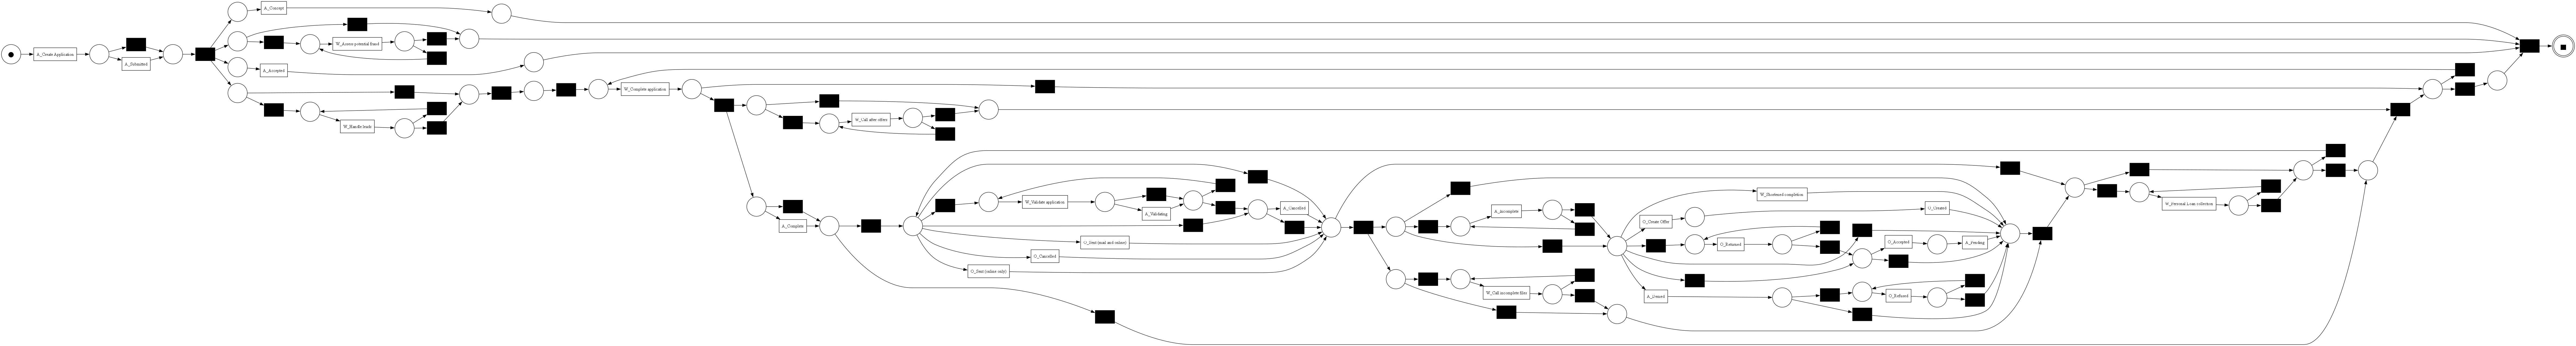

In [13]:
pm4py.view_petri_net(repaired_net, repaired_im, repaired_fm)

In [ ]:
pm4py.write_pnml(repaired_net, repaired_im, repaired_fm, f"{OUTPUT_DIR}/changed_model.pnml")

## Task c: Compare and conclude.
**How do the bottlenecks and the repair/change hold up across the three logs?**
- The clean log identifies the true bottlenecks of the process, with activities such as `W_Personal Loan collection` and `A_Cancelled` having the longest waiting times. In the noised log, the activity names become corrupted by additional case identifiers, causing the timing results to fragment and making the bottlenecks difficult to identify correctly. After recovery, the timing values are very close to those of the clean log, showing that the recovery process successfully restores the original process behaviour. For the model change, removing the `skip_27` τ transition reduced fitness slightly from 1.0000 to 0.9741 while increasing precision from 0.1407 to 0.3685, resulting in a more accurate and less over-generalised process model.

**Explain which timing figures and which repair you trust, and how the injected noise distorts the performance annotation and could mislead the repair (change)**
- The timing figures from the clean log are the most trustworthy because they are based on the original event data without artificial modifications. The recovered log is also reliable because its timing results closely match those of the clean log. In contrast, the noised log cannot be trusted for performance analysis because the injected noise changes activity labels, preventing events from being grouped correctly and producing misleading waiting and processing times. Similarly, if a model change were performed on the noised log, the change decisions could be influenced by behaviour caused by noise rather than the actual process, resulting in unnecessary or incorrect model changes.

**State why a genuine fault is one that shows on the clean log rather than only under noise**
- A genuine fault is one that is present in the clean log because it reflects the actual behaviour of the business process rather than errors introduced during data manipulation. Problems that appear only in the noised log are likely to be artefacts of the injected noise, such as corrupted activity names or altered event information, and do not represent real process issues. Therefore, conclusions about bottlenecks or model improvements should be based primarily on the clean log, while the recovered log can be used to verify that the recovery process has successfully restored the original behaviour.